# Layered (ANN-style) representation of the MFAS-ordered mouse connectome — v1 prototype

**Goal.** Take the champion MFAS order `pi` (H63) and re-draw the graph the way
artificial neural networks are drawn: nodes assigned to **layers** with no
intra-layer feedforward edge, edges allowed to skip layers, feedback drawn as
separate red arcs, and nodes ordered inside each layer to keep the number of
edge **crossings** low.

Fixed decisions (v1) — full spec in `layering/README.md`:

1. feedback edges are drawn as separate arcs, never reversed or dropped;
2. HARD layering (zero intra-layer FF edges); the soft version is future work;
3. edges may skip layers; 4. crossings are counted, not weighted;
5. mouse first (148 nodes), fly connectome later; 6. deliverable = picture + structure;
7. `pi` is the fixed input (joint layer/order optimization is deferred, T5);
8. sources/sinks are just the first/last layers; 9. within-layer order = barycenter v1.

Two layer-assignment methods are compared side by side (decision T2):

- **A. FF-DAG longest-path** — earliest feasible layer; fewest layers; may
  reorder nodes relative to `pi` on FF-incomparable pairs, so some
  `pi`-feedback can be **reclaimed** (become forward-by-layer);
- **B. pi-slices** — layers are contiguous slices of `pi`; `pi` fully
  preserved; feedback can never be reclassified.

## Configuration

All hyperparameters live in `CONFIG` (no magic numbers). Seeds are set even
though every step below is deterministic — reproducibility by convention.

In [1]:
CONFIG = {
    "dataset": "mouse",                 # v1 target (decision 5)
    "barycenter_sweeps": 10,            # within-layer ordering budget (decision 9)
    "figure_dpi": 120,
    "outputs_dir": "outputs",           # relative to layering/
    "global_seed": 42,
}

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "src" / "mfas").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("repo root not found above cwd")
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from layering import core, draw, io_utils

np.random.seed(CONFIG["global_seed"])
OUT = REPO_ROOT / "layering" / CONFIG["outputs_dir"]
OUT.mkdir(exist_ok=True)
print("repo root:", REPO_ROOT)

repo root: D:\1\bot\UHaifa\deep_learning\mfas_autoresearch\nn_backward_connections


## Load the graph and the champion order (parity-gated)

The order comes from the **tracked** champion artifact
`results/champions/H63_mouse_s42_cuda.npz` (pinned by `tools/pin_champion.py`).
`io_utils` re-scores it through the frozen oracle and compares against
`autoresearch/sota.json` — a stale or wrong artifact raises instead of
silently layering a non-champion order.

In [2]:
g, order, rank, ff_pct = io_utils.load_graph_and_champion_order(CONFIG["dataset"])
print(f"dataset: {g.name}  nodes: {g.n_nodes}  edges: {g.n_edges}  "
      f"total weight: {g.total_weight:.6f}")
print(f"champion feedforward pct (verified vs sota.json): {ff_pct:.11f}")

dataset: mouse  nodes: 148  edges: 583  total weight: 9.159036
champion feedforward pct (verified vs sota.json): 93.17538325904


## Step 0 — split edges by the order `pi`

An edge `(u, v)` is **feedforward** iff `rank[u] < rank[v]`; everything else
is feedback. Mutual pairs (both `u->v` and `v->u` present) put a hard floor
under feedback: one direction of each pair is backward under ANY order and
ANY valid layering.

In [3]:
ff = core.ff_mask_by_order(g.src, g.tgt, rank)
mutual = core.mutual_edge_mask(g.src, g.tgt)
w = np.asarray(g.weight, dtype=np.float64)
total_w = w.sum()
n_fb = int((~ff).sum())
print(f"FF edges: {int(ff.sum())} ({100 * w[ff].sum() / total_w:.4f}% of weight)")
print(f"FB edges: {n_fb} ({100 * w[~ff].sum() / total_w:.4f}% of weight)")
print(f"mutual pairs: {int(mutual.sum()) // 2}; FB edges that are halves of "
      f"mutual pairs: {int(((~ff) & mutual).sum())} of {n_fb} "
      f"(unreclaimable by any layering)")

FF edges: 459 (93.1754% of weight)
FB edges: 124 (6.8246% of weight)
mutual pairs: 83; FB edges that are halves of mutual pairs: 83 of 124 (unreclaimable by any layering)


## Layer assignment — methods A and B side by side

Hard invariants are asserted, not assumed: every FF edge must strictly
increase the layer (both methods), B must be monotone along `pi`, and A
(earliest-feasible) must be pointwise ≤ B.

In [4]:
layer_A = core.layers_longest_path(g.src, g.tgt, ff, order)
layer_B = core.layers_pi_slices(g.src, g.tgt, ff, order)

for name, layer in (("A", layer_A), ("B", layer_B)):
    assert np.all(layer[g.src[ff]] < layer[g.tgt[ff]]), f"intra/backward FF edge in {name}"
assert np.all(np.diff(layer_B[order]) >= 0), "B is not monotone along pi"
assert np.all(layer_A <= layer_B), "A is not pointwise minimal"
print("hard invariants OK")

stats_A = core.layout_stats(g.src, g.tgt, g.weight, rank, layer_A, "A: FF-DAG longest-path")
stats_B = core.layout_stats(g.src, g.tgt, g.weight, rank, layer_B, "B: pi-slices")
scalar_keys = [k for k in stats_A if k not in ("widths", "span_hist")]
pd.DataFrame([{k: s[k] for k in scalar_keys} for s in (stats_A, stats_B)]).set_index("method").T

hard invariants OK


method,A: FF-DAG longest-path,B: pi-slices
n_layers,26.000000,49.000000
max_width,43.000000,19.000000
mean_width,5.692308,3.020408
edges_fwd,459.000000,459.000000
edges_intra,0.000000,0.000000
edges_back,124.000000,124.000000
w_fwd_pct,93.175383,93.175383
w_intra_pct,0.000000,0.000000
w_back_pct,6.824617,6.824617
w_ff_pi_pct,93.175383,93.175383


## Feedback reclamation (decision T2)

Edge classes on the drawing are **by layers**, not by `pi`. Method A can move
an FF-incomparable node into an early layer, turning a `pi`-feedback edge
into a forward-by-layer edge ("reclaimed"). Method B cannot, by construction.
Here we measure how much that freedom is actually worth on the mouse graph —
and certify each feedback edge as reclaimable-or-not via FF-path
reachability: an FF path `target -> source` forces `layer[target] <
layer[source]` in EVERY hard layering, so such an edge is unreclaimable in
principle, not just unreclaimed by longest-path.

In [5]:
rows = []
for name, layer in (("A: FF-DAG longest-path", layer_A), ("B: pi-slices", layer_B)):
    cls = core.classify_by_layers(g.src, g.tgt, layer)
    reclaimed = (~ff) & (cls == core.FORWARD)
    intra = cls == core.INTRA
    rows.append({
        "method": name,
        "reclaimed_fb_edges": int(reclaimed.sum()),
        "reclaimed_fb_weight_pct": 100 * w[reclaimed].sum() / total_w,
        "intra_layer_edges": int(intra.sum()),
        "fwd_by_layer_weight_pct": 100 * w[cls == core.FORWARD].sum() / total_w,
        "ff_by_pi_weight_pct": 100 * w[ff].sum() / total_w,
    })
    if 0 < int(reclaimed.sum()) <= 20:
        for e in np.where(reclaimed)[0].tolist():
            print(f"  {name}: reclaimed edge {int(g.src[e])} -> {int(g.tgt[e])} "
                  f"(layers {int(layer[g.src[e]])} -> {int(layer[g.tgt[e]])}, "
                  f"w={float(w[e]):.6f})")

# certification: which FB edges could ANY hard layering reclaim?
fb_idx = np.where(~ff)[0]
blocked = core.ff_path_exists_mask(g.src, g.tgt, ff,
                                   g.tgt[fb_idx], g.src[fb_idx])
n_blocked, n_fb = int(blocked.sum()), len(fb_idx)
n_mutual_fb = int(mutual[fb_idx].sum())
print(f"FB edges with an FF path target->source "
      f"(unreclaimable in ANY hard layering): {n_blocked} of {n_fb}")
print(f"  of which direct mutual-pair reverses: {n_mutual_fb}; "
      f"longer FF paths: {n_blocked - n_mutual_fb}")
print(f"FB edges reclaimable in principle (no FF path back): {n_fb - n_blocked}")
pd.DataFrame(rows).set_index("method").T

FB edges with an FF path target->source (unreclaimable in ANY hard layering): 124 of 124
  of which direct mutual-pair reverses: 83; longer FF paths: 41
FB edges reclaimable in principle (no FF path back): 0


method,A: FF-DAG longest-path,B: pi-slices
reclaimed_fb_edges,0.000000,0.000000
reclaimed_fb_weight_pct,0.000000,0.000000
intra_layer_edges,0.000000,0.000000
fwd_by_layer_weight_pct,93.175383,93.175383
ff_by_pi_weight_pct,93.175383,93.175383


## Within-layer ordering — crossings before and after barycenter

Initial slots follow `pi` inside each layer; the barycenter heuristic then
sweeps left-to-right / right-to-left, sorting each layer by the mean current
y of its neighbours on the swept-from side. The crossing count is the number
of **proper geometric crossings of the straight segments actually drawn**
(forward-by-layer edges only; feedback arcs are outside the objective, T4).

In [6]:
layouts = {}
rows = []
for name, layer in (("A", layer_A), ("B", layer_B)):
    slot0 = core.initial_slots_from_order(layer, rank)
    mask_fwd = core.classify_by_layers(g.src, g.tgt, layer) == core.FORWARD
    x = layer.astype(np.float64)
    c0 = core.count_crossings(g.src, g.tgt, mask_fwd, x, core.y_coords(layer, slot0))
    slot, c_best = core.barycenter_order(g.src, g.tgt, mask_fwd, layer, slot0,
                                         CONFIG["barycenter_sweeps"])
    layouts[name] = (layer, slot)
    rows.append({"method": name,
                 "crossings_pi_order": c0,
                 "crossings_barycenter": c_best,
                 "reduction_pct": (100.0 * (c0 - c_best) / c0) if c0 else 0.0})
pd.DataFrame(rows).set_index("method")

,crossings_pi_order,crossings_barycenter,reduction_pct
method,,,
A,16205,10435,35.606294
B,18517,11444,38.197332


## Drawing — method A (FF-DAG longest-path layers)

Blue straight segments: forward-by-layer (always left → right, so no
arrowheads). Red arcs: feedback-by-layer. Orange arcs (if any): intra-layer
edges between FF-incomparable nodes (T1). Line width encodes edge weight
(presentation only — the crossing objective stays unweighted).

saved: D:\1\bot\UHaifa\deep_learning\mfas_autoresearch\nn_backward_connections\layering\outputs\layering_mouse_ffdag.png


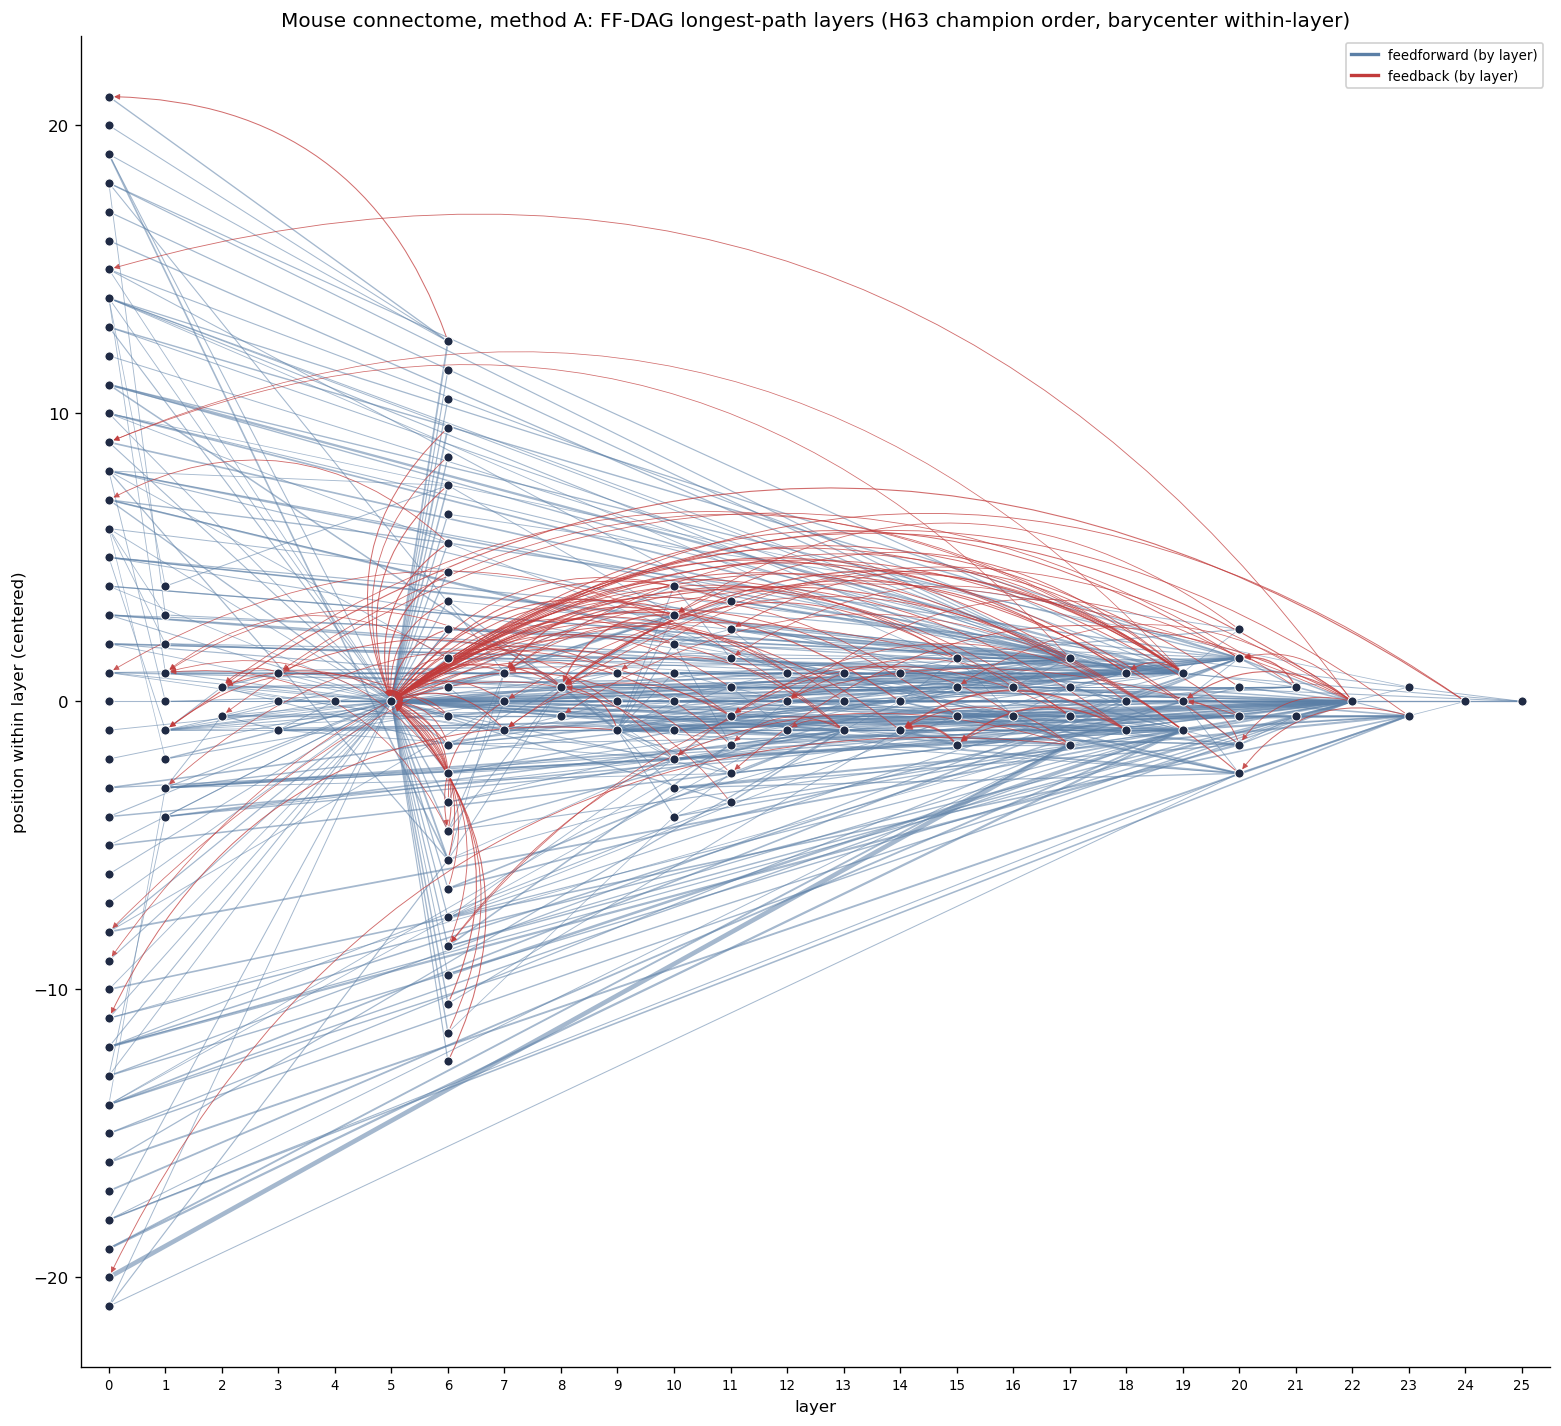

In [7]:
layer, slot = layouts["A"]
fig, ax = draw.draw_layered(
    g.src, g.tgt, g.weight, layer, slot, dpi=CONFIG["figure_dpi"],
    title="Mouse connectome, method A: FF-DAG longest-path layers "
          "(H63 champion order, barycenter within-layer)")
fig.savefig(OUT / "layering_mouse_ffdag.png", dpi=CONFIG["figure_dpi"],
            bbox_inches="tight")
print("saved:", OUT / "layering_mouse_ffdag.png")

## Drawing — method B (pi-slices layers)

Same graph, same conventions; layers are contiguous slices of the champion
order, so reading the x-axis left to right reproduces `pi` exactly.

saved: D:\1\bot\UHaifa\deep_learning\mfas_autoresearch\nn_backward_connections\layering\outputs\layering_mouse_pislices.png


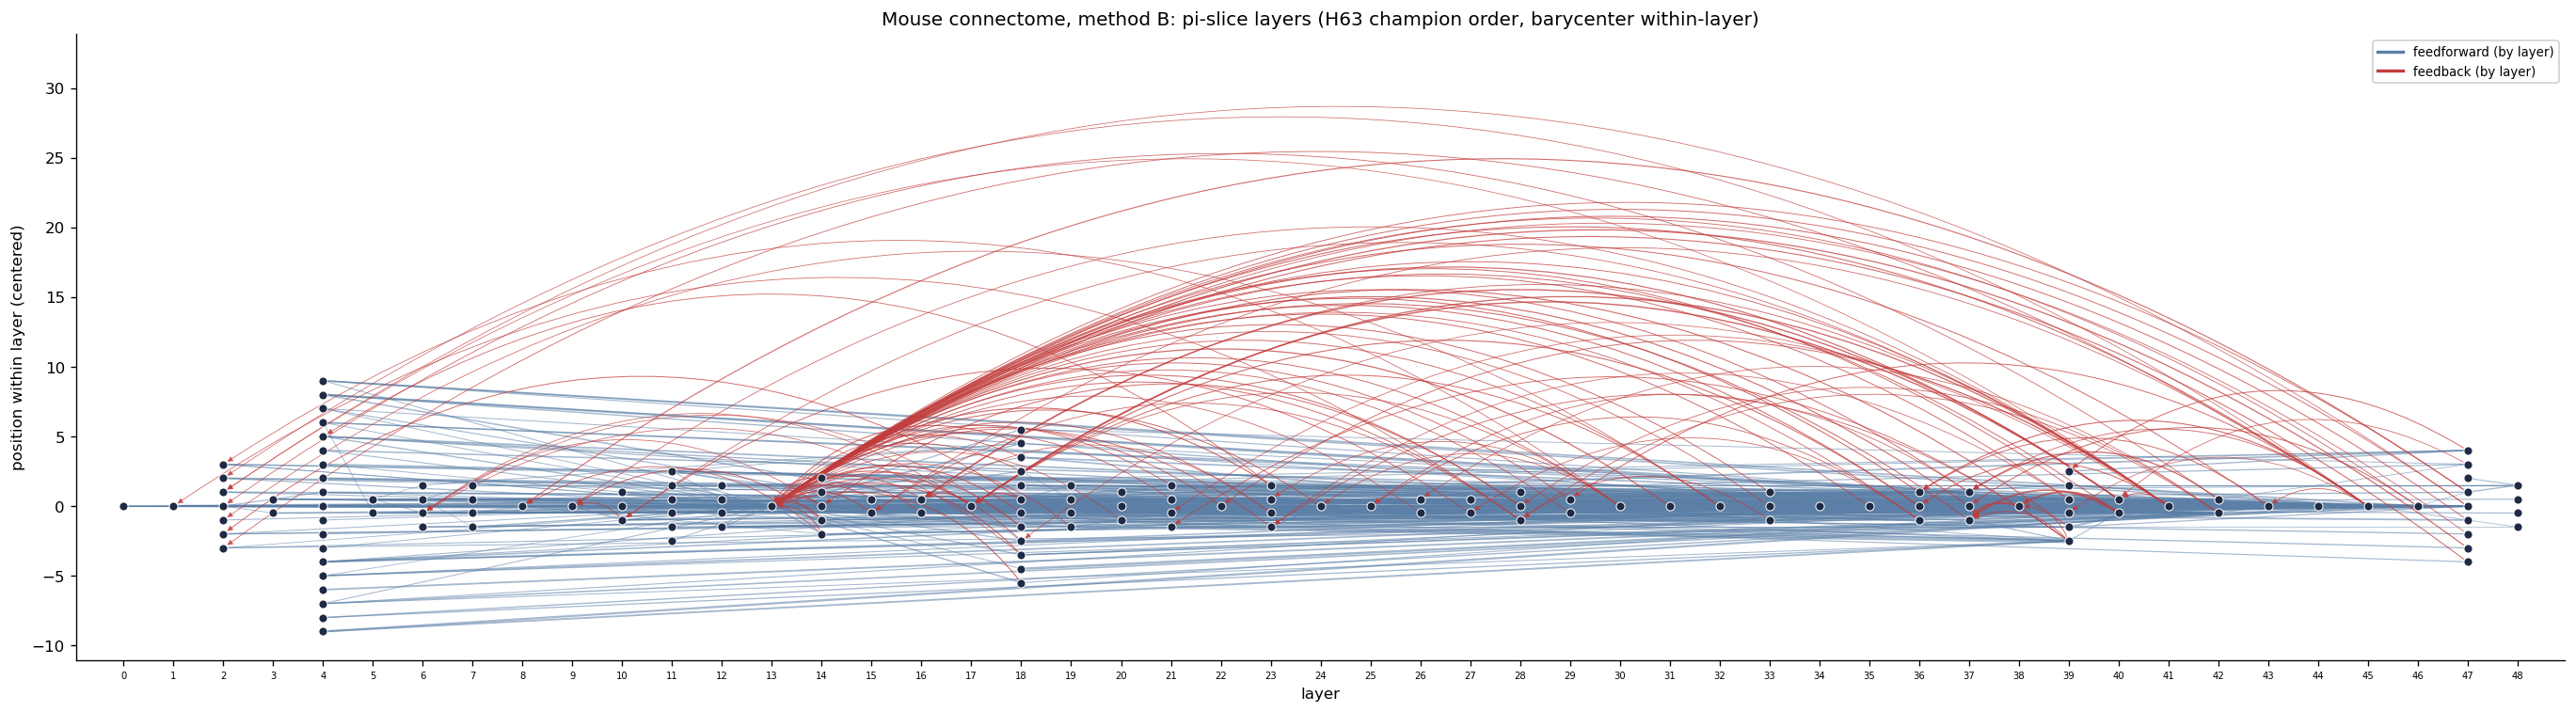

In [8]:
layer, slot = layouts["B"]
fig, ax = draw.draw_layered(
    g.src, g.tgt, g.weight, layer, slot, dpi=CONFIG["figure_dpi"],
    title="Mouse connectome, method B: pi-slice layers "
          "(H63 champion order, barycenter within-layer)")
fig.savefig(OUT / "layering_mouse_pislices.png", dpi=CONFIG["figure_dpi"],
            bbox_inches="tight")
print("saved:", OUT / "layering_mouse_pislices.png")

## Structure — width profiles and forward-edge span

The "structure" half of the deliverable (decision 6): how wide each layer is,
and how far forward edges jump (span 1 = adjacent layers, like a textbook
ANN; larger span = skip connections). These profiles are what we will later
compare against degree-matched random graphs (project research goal 2).

saved: D:\1\bot\UHaifa\deep_learning\mfas_autoresearch\nn_backward_connections\layering\outputs\layering_mouse_structure.png


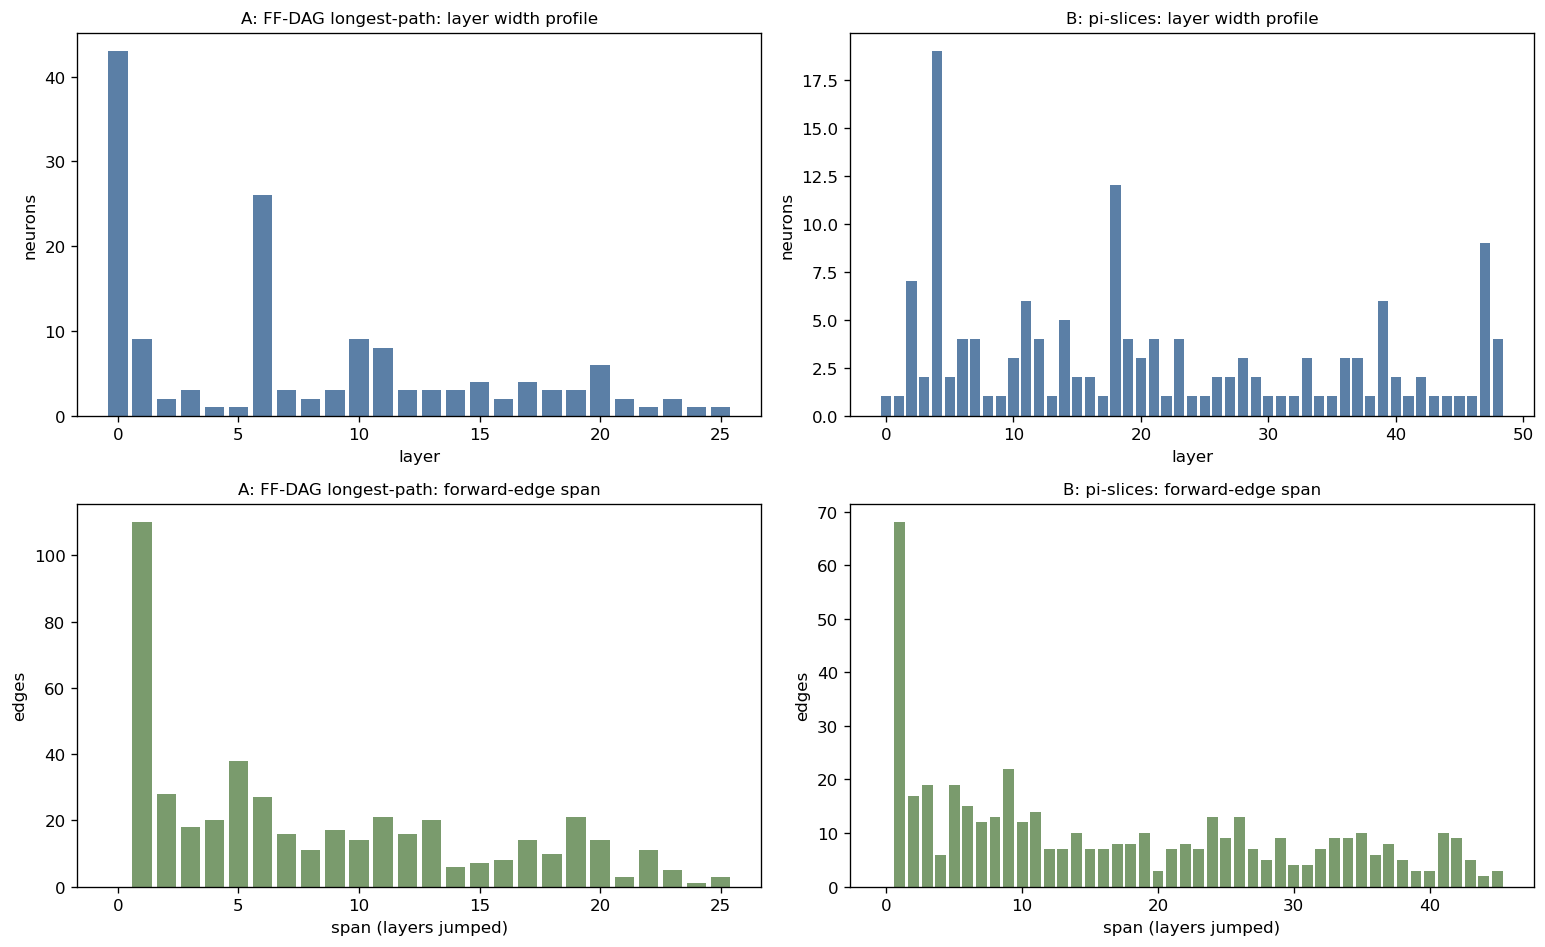

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=CONFIG["figure_dpi"])
for j, stats in enumerate((stats_A, stats_B)):
    ax = axes[0][j]
    ax.bar(range(len(stats["widths"])), stats["widths"], color="#5b7fa6")
    ax.set_title(f"{stats['method']}: layer width profile", fontsize=10)
    ax.set_xlabel("layer")
    ax.set_ylabel("neurons")
    ax = axes[1][j]
    ax.bar(range(len(stats["span_hist"])), stats["span_hist"], color="#7a9b6d")
    ax.set_title(f"{stats['method']}: forward-edge span", fontsize=10)
    ax.set_xlabel("span (layers jumped)")
    ax.set_ylabel("edges")
fig.tight_layout()
fig.savefig(OUT / "layering_mouse_structure.png", dpi=CONFIG["figure_dpi"],
            bbox_inches="tight")
print("saved:", OUT / "layering_mouse_structure.png")

## Observations and next steps

Headline structure of the result (numbers from the tables above, H63 order):

- Method **A** compresses the 148-neuron line into **26 layers** vs **49**
  for method **B**, at the price of reordering FF-incomparable nodes
  relative to `pi`. Layer 0 under A is wide (43 neurons): every neuron with
  no FF in-edge slides to the front.
- **Reclamation is exactly zero on the mouse graph, and certifiably so** —
  the reclamation cell shows all 124 feedback edges have an FF path
  `target -> source` (83 direct mutual-pair reverses + 41 longer paths), so
  NO hard layering of this order can reclaim ANY of them: the
  93.1754% / 6.8246% split is a ceiling for layered drawings of the H63
  order, and both methods sit exactly on it (0 reclaimed, 0 intra-layer).
  Whether reclamation stays zero on the fly connectome is an open question
  for the scale-up.
- The barycenter pass removes **~36%** of crossings under A
  (16,205 → 10,435) and **~38%** under B (18,517 → 11,444). The residual is
  dominated by long skip edges (mean span 8.2 layers under A, 16.6 under B;
  only 24% / 15% of forward edges connect adjacent layers) — exactly what
  the T3(a) upgrade (span-minimizing layer assignment) is meant to attack.
- Both drawings and all statistics come from the same `(layer, slot)` arrays
  and the same classifier, so the pictures cannot disagree with the tables.

Next steps (from the README roadmap): T3(a) span-minimizing layer
assignment; the soft-layering variant (fixed L); a dedicated within-layer
objective; scaling strategy for the fly connectome; null-model comparison
(real connectome vs degree-matched random graphs); and the deferred T5
joint 2D relaxation reusing the Rocket machinery.